# Emoji Usage Patterns in Tweets

## Introduction

Emojis are widely used in online communication. They help express emotions, tone, and meaning that text alone may not fully capture. 

This project explores how emojis are used in tweets and how the usage differs across sentiment labels. Understanding these patterns can help reveal how visual symbols contribute to emotional expression in online discourse.

## Dataset

The dataset used in this project is [TweetFeels 1m4](https://huggingface.co/datasets/mnemoraorg/tweetfeels-1m4), a large-scale collection of labeled tweets available on Hugging Face. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emoji

from collections import Counter

import plotly.io as pio
pio.renderers.default = "notebook_connected"

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kaleido
import os

# Load TweetFeels-1m from Hugging Face
from datasets import load_dataset

dataset = load_dataset("mnemoraorg/tweetfeels-1m4")
df = dataset["train"].to_pandas()

df.head()

,Text,Language,Label
0,@Charlie_Corley @Kristine1G @amyklobuchar @Sty...,en,litigious
1,#BadBunny: Como dos gotas de agua: Joven se di...,es,negative
2,https://t.co/YJNiO0p1JV Flagstar Bank disclose...,en,litigious
3,Rwanda is set to host the headquarters of Unit...,en,positive
4,OOPS. I typed her name incorrectly (today’s br...,en,litigious


In [2]:
df.shape

(937854, 3)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937854 entries, 0 to 937853
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Text      937854 non-null  object
 1   Language  937831 non-null  object
 2   Label     937854 non-null  object
dtypes: object(3)
memory usage: 21.5+ MB


In [4]:
df.columns = df.columns.str.lower()
df["label"].value_counts()

label
positive       264545
negative       262220
uncertainty    206940
litigious      204149
Name: count, dtype: int64

Text(0.5, 1.0, 'Label Distribution')

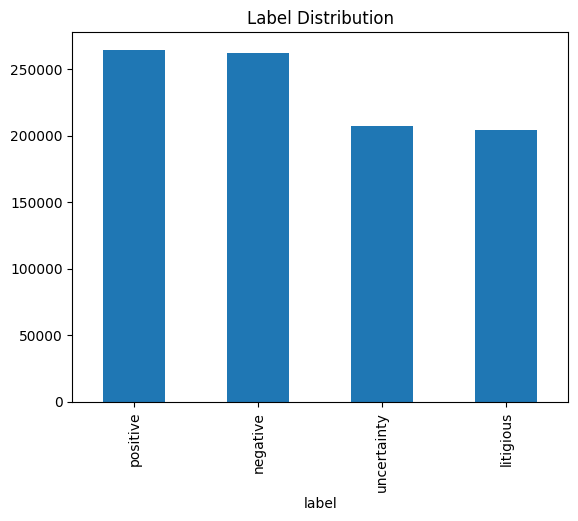

In [5]:
df["label"].value_counts().plot(kind = "bar")
plt.title("Label Distribution")

In [6]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

df.groupby("label")[["char_len", "word_len"]].mean()

,char_len,word_len
label,,
litigious,175.637054,27.433958
negative,158.675223,26.062097
positive,150.677276,23.523178
uncertainty,161.057316,26.424514


## Emoji Extraction

In [7]:
def extract_emojis(text):
    if pd.isna(text):
        return []
    return [e["emoji"] for e in emoji.emoji_list(text)]

df["emojis"] = df["text"].apply(extract_emojis)

df["emoji_count"] = df["emojis"].str.len()
df["has_emoji"] = df["emoji_count"] > 0

## Emoji Usage Across Labels

In [8]:
usage = df.groupby("label").agg(
    tweets = ("text", "size"),
    emoji_rate = ("has_emoji", "mean"),
    mean_emoji = ("emoji_count", "mean")
)

usage

,tweets,emoji_rate,mean_emoji
label,,,
litigious,204149,0.098795,0.207995
negative,262220,0.142827,0.280982
positive,264545,0.216458,0.471973
uncertainty,206940,0.149990,0.279724


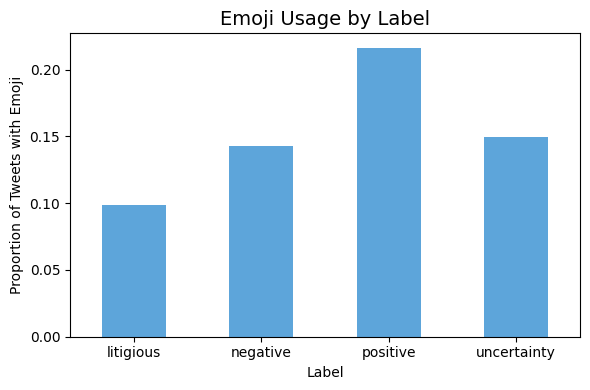

In [9]:
ax = usage["emoji_rate"].plot(
    kind="bar",
    figsize=(6,4),
    color="#5DA5DA"
)

ax.set_title("Emoji Usage by Label", fontsize=14)
ax.set_ylabel("Proportion of Tweets with Emoji")
ax.set_xlabel("Label")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In general, tweets with positive labels tend to include emojis more often.

## Most Frequent Emojis

Here we look at the most commonly used emojis in the dataset.

In [10]:
all_emojis = [e for lst in df["emojis"] for e in lst]

emoji_counts = Counter(all_emojis)

top20 = pd.DataFrame(
    emoji_counts.most_common(20),
    columns = ["emoji", "count"]
)

top20.head()

,emoji,count
0,😂,28717
1,😭,18545
2,🤣,14454
3,❤️,7799
4,🔥,5452


In [11]:
fig = px.bar(
    top20,
    x="count",
    y="emoji",
    orientation="h",
    title="Top 20 Most Used Emojis",
    labels={"count": "Frequency", "emoji": "Emoji"}
)

fig.update_layout(yaxis=dict(categoryorder="total ascending"))

fig.show()

In [12]:
fig.write_html("outputs/top20_emojis.html")
fig.write_image("outputs/top20_emojis.png")

![Top20 Emoji](outputs/top20_emojis.jpg)

In [13]:
emoji_df = df.explode("emojis")

emoji_label_rank = (
    emoji_df
    .groupby(["label", "emojis"])
    .size()
    .reset_index(name="count")
)

top_per_label = (
    emoji_label_rank
    .sort_values(["label", "count"], ascending=[True, False])
    .groupby("label")
    .head(10)
)

In [14]:
dfs = []

labels = top_per_label["label"].unique()

for lbl in labels:
    # Select top N emojis for this label
    df_lbl = top_per_label[top_per_label["label"] == lbl].copy()
    df_lbl = df_lbl.sort_values("count", ascending=False).head(10)
    
    # Combine emoji + count into one column for display
    df_lbl = df_lbl.reset_index(drop=True)
    df_lbl[f"{lbl}"] = df_lbl["emojis"] + " (" + df_lbl["count"].astype(str) + ")"
    
    dfs.append(df_lbl[[f"{lbl}"]])  

# Concatenate side by side
top_emojis_side_by_side = pd.concat(dfs, axis=1)

top_emojis_side_by_side

,litigious,negative,positive,uncertainty
0,😂 (4084),😂 (10338),😭 (5769),😂 (8551)
1,🤣 (2805),😭 (7982),😂 (5744),😭 (3308)
2,😭 (1486),🤣 (5482),❤️ (5058),🤣 (2883)
3,🔥 (1124),💔 (1349),🤣 (3284),🤔 (1617)
4,🤔 (833),❤️ (1175),🔥 (3084),❤️ (1074)
5,🚨 (798),🤔 (1121),😍 (2892),🥺 (1017)
6,✅ (669),💀 (1032),✨ (2872),😅 (827)
7,🤡 (634),🙄 (983),🥰 (2058),👀 (809)
8,🙄 (565),😅 (949),💜 (1812),🙄 (738)
9,👇 (554),🙏 (863),👏 (1600),😉 (677)


In [15]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=top_per_label["label"].unique()
)

labels = top_per_label["label"].unique()

positions = [(1,1),(1,2),(2,1),(2,2)]

for label, (r,c) in zip(labels, positions):

    group = top_per_label[top_per_label["label"] == label]
    
    group = group.sort_values("count")

    fig.add_trace(
        go.Bar(
            x=group["count"],
            y=group["emojis"],
            orientation="h"
        ),
        row=r,
        col=c
    )

fig.update_layout(
    height=700,
    width=900,
    showlegend=False,
    title="Top 10 Emojis by Label"
)

fig.show()

In [16]:
fig.write_html("outputs/top10_per_label.html")
fig.write_image("outputs/top10_per_label.png")

![Top10 per label](outputs/top_10_by_label.png)

## Emoji-Label Heatmap

The heatmap shows how frequently each emoji appears in different labels.

In [17]:
emoji_label_counts = pd.crosstab(
    emoji_df["emojis"],
    emoji_df["label"]
)

top_emojis = emoji_label_counts.sum(axis=1).nlargest(20).index
emoji_label_counts = emoji_label_counts.loc[top_emojis]

emoji_label_freq = emoji_label_counts.div(
    emoji_label_counts.sum(axis=1),
    axis=0
)

emoji_label_counts.head()

label,litigious,negative,positive,uncertainty
emojis,,,,
😂,4084,10338,5744,8551
😭,1486,7982,5769,3308
🤣,2805,5482,3284,2883
❤️,492,1175,5058,1074
🔥,1124,757,3084,487


In [18]:
emoji_label_freq.head(5)

label,litigious,negative,positive,uncertainty
emojis,,,,
😂,0.142215,0.359996,0.200021,0.297768
😭,0.080129,0.430413,0.311081,0.178377
🤣,0.194064,0.379272,0.227204,0.199460
❤️,0.063085,0.150660,0.648545,0.137710
🔥,0.206163,0.138848,0.565664,0.089325


In [19]:
fig = px.imshow(
    emoji_label_freq.T.values,   # transpose
    x=emoji_label_freq.index,    # emojis
    y=emoji_label_freq.columns,  # labels
    text_auto=".2f",
    color_continuous_scale="YlOrRd"
)

fig.update_xaxes(
    tickmode="array",
    tickvals=list(range(len(emoji_label_freq.index))),
    ticktext=emoji_label_freq.index
)

fig.show()

In [20]:
fig.write_html("outputs/heatmap.html")
fig.write_image("outputs/heatmap.png")

![heatmap](outputs/frequency_heatmap.jpg)

This heatmap shows the distribution of sentiment labels across 20 emojis. Each column represents an emoji, and the values indicate the proportion of times that emoji appears in tweets associated with a given sentiment. 

- Emojis such as ❤️, 😍, and ✨ are highly concentrated in the positive category, suggesting they are strong indicators of positive sentiment. This is reflected by the positive row having higher proportions compared to other categories, showing stronger concentration. 

- In contrast, emojis like 😂, 😭, 🤣, and 💀 have relatively higher proportions in the negative category (around 0.35–0.45), indicating they are often used in negative or sarcastic contexts. 

- The uncertainty category is more evenly distributed across emojis, suggesting it is less strongly associated with specific symbols. 

- Finally, the litigious category shows generally low and uniform proportions, indicating that emojis are not strong indicators of legal-related language, at least among the top 20 most frequent emojis.

## Emoji Frequency Distribution

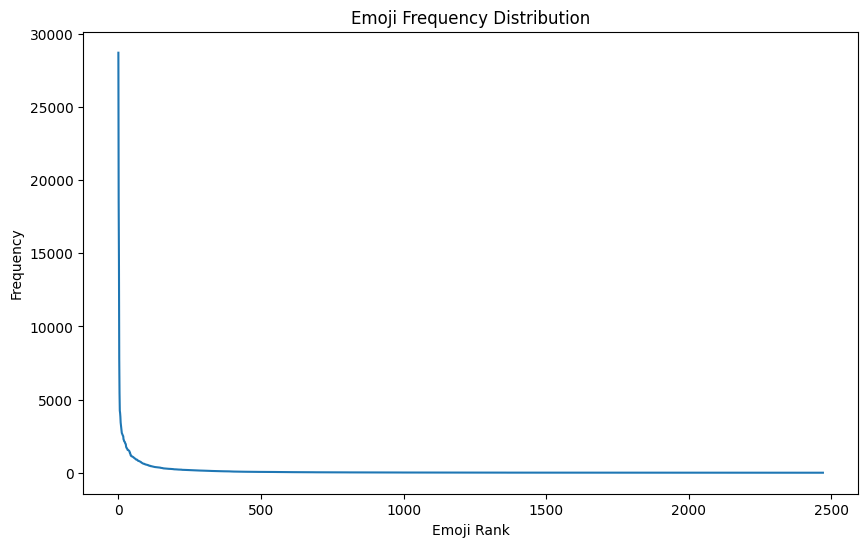

In [21]:
emoji_counts = emoji_df["emojis"].value_counts()

plt.figure(figsize=(10, 6))
plt.plot(range(len(emoji_counts)), emoji_counts.values)

plt.title("Emoji Frequency Distribution")
plt.xlabel("Emoji Rank")
plt.ylabel("Frequency")

plt.show()

The emoji frequency follows a long-tail pattern.

This means a small number of emojis are used very often, while most emojis appear only rarely. This distribution is consistent with Zipf-like 
behavior commonly observed in natural language data. 

## Distribution of Emojis per Tweet

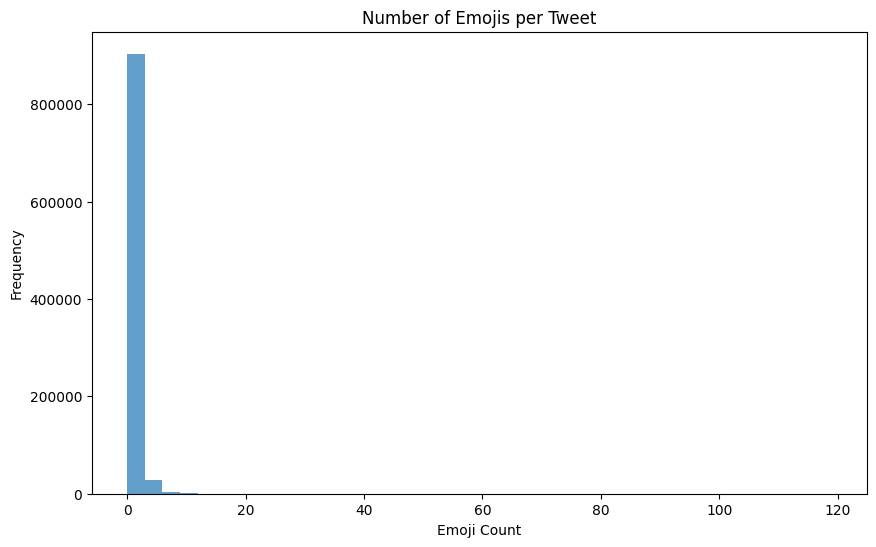

In [22]:
df["emoji_count"] = df["emojis"].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(df["emoji_count"], bins=40, alpha=0.7)

plt.title("Number of Emojis per Tweet")
plt.xlabel("Emoji Count")
plt.ylabel("Frequency")
plt.show()

In [23]:
df.loc[df["emoji_count"] > 0, "emoji_count"].describe()

count    145923.000000
mean          2.048238
std           2.326181
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         119.000000
Name: emoji_count, dtype: float64

Most tweets use very few emojis. The majority contain only one emoji, and 75% of tweets have two or fewer.

However, a small number of tweets contain many emojis. These outliers are often tweets where the same emoji is repeated many times, which can inflate its frequency and bias the emoji–label association analysis.

More robust methods, such as log-odds with smoothing, are needed to reduce the impact of rare but extreme observations.

Overall, emoji usage is sparse and uneven, which should be considered when interpreting emoji–label associations in the following analysis.

In [24]:
df.to_csv('emoji.csv')
emoji_df.to_csv('emoji_exploded.csv')